In [1]:
import pandas as pd

In [ ]:
def read_clean(path:str, nheader=7) -> pd.DataFrame:
    df = pd.read_excel(path, header=nheader)
    df = df.drop(columns=["Line", "Unnamed: 2"])
    df = df.rename(columns={"Unnamed: 1": "category"})
    year_cols = [c for c in df.columns if c != "category"]
    df[year_cols] = df[year_cols].apply(pd.to_numeric, errors="coerce")
    df = df.dropna(thresh=10)
    return df

In [36]:
# df = read_clean("../data/original(do not modify)/Personal_income_by_state(billions).xlsx",5)
df = pd.read_excel("../data/original(do not modify)/Personal_income_by_state(billions).xlsx",header=5)
    
df.head()

/home/kien/torch_cuda/lib/python3.13/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,GeoFIPS,GeoName,LineCode,Description,1929,1930,1931,1932,1933,1934,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,00000,United States,1.0,Personal income (millions of dollars),85151,76394,65531,50162,47114,53967,...,15884741.0,16658962.0,17514402.0,18349584.0,19613059.0,21484168.0,22144814.0,23577208.0,24897613.0,26109831.2
1,00000,United States,2.0,Population (persons) 1,121769000,123075000,124038000,124839000,125580000,126372000,...,324353340.0,326608609.0,328529577.0,330226227.0,331578104.0,332100166.0,333996304.0,336755052.0,340003797.0,341784857.0
2,00000,United States,3.0,Per capita personal income (dollars) 2,699,621,528,402,375,427,...,48974.0,51006.0,53311.0,55567.0,59151.0,64692.0,66303.0,70013.0,73227.0,76393.0
3,01000,Alabama,1.0,Personal income (millions of dollars),843.2,697.5,583.7,421.9,435.6,556.3,...,190871.8,197963.8,205674.2,215151.8,230878.4,255682.3,262425.8,279484.6,295590.5,309906.4
4,01000,Alabama,2.0,Population (persons) 1,2644000,2647000,2649000,2653000,2661000,2685000,...,4931579.0,4953096.0,4977088.0,5003778.0,5032962.0,5050058.0,5076868.0,5117850.0,5163055.0,5193088.0


# Inflation

In [37]:
df = read_clean(
    "../data/original(do not modify)/GDP_and_personal_income/Personal_Income_and_Outlays/Annual_T2.3.7._Percent_Change_From_Preceding_Period_in_Prices_for_Personal_Consumption_Expenditures_by_Major_Type_of_Product.xlsx",
)
df.head()

,category,1930,1931,1932,1933,1934,1935,1936,1937,1938,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Personal consumption expenditures (PCE),-4.2,-10.7,-11.8,-3.6,4.5,2.5,0.9,3.6,-2.3,...,1.0,1.7,2.0,1.4,1.1,4.1,6.5,3.8,2.6,2.6
1,Goods,-5.3,-13.8,-13.8,-0.8,9.9,2.7,0.4,3.6,-4.1,...,-1.6,0.3,0.8,-0.4,-0.8,4.9,8.6,1.2,-0.4,0.7
2,Durable goods,-5.9,-10.7,-11.9,-2.4,6,-0.6,0.6,4.1,-0.1,...,-2.2,-2.3,-1.4,-1.0,-0.9,5.5,6.5,-0.7,-2.1,0.4
3,Motor vehicles and parts,-3.7,-6.7,-6.2,-6.2,4.7,-1.5,0.5,2.5,4,...,-0.6,-1.3,0.0,0.8,1.6,11.4,11.7,0.1,-2.0,1.3
4,Furnishings and durable household equipment,-3.8,-11.2,-13.7,0.3,8.1,0.6,0.7,6.7,-1.8,...,-2.7,-2.8,-1.0,0.7,0.9,5.1,9.2,-0.8,-3.1,0.8


In [38]:
df[df.isna().any(axis=1)]

,category,1930,1931,1932,1933,1934,1935,1936,1937,1938,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025


In [39]:
df.describe()

,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,...,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,3.716129,4.148387,4.287097,2.874194,2.193548,2.019355,1.800000,1.777419,1.909677,1.345161,...,0.164516,1.703226,2.012903,0.893548,0.032258,5.387097,7.680645,2.932258,1.806452,2.045161
std,2.129960,2.858539,3.658574,2.892515,2.900912,2.355762,1.496217,1.701707,2.285951,2.340205,...,3.248646,3.108749,2.966338,1.899638,3.809146,6.307125,6.365345,3.882816,2.871577,1.967374
min,-1.200000,-6.500000,-8.400000,-7.500000,-9.100000,-5.300000,-2.100000,-4.200000,-7.100000,-8.400000,...,-11.400000,-3.700000,-3.300000,-4.000000,-15.000000,0.500000,0.500000,-10.200000,-5.400000,-4.900000
25%,2.800000,3.800000,3.850000,2.150000,1.200000,0.900000,1.050000,1.150000,1.650000,0.700000,...,-0.950000,0.350000,0.650000,0.150000,-0.750000,2.900000,5.100000,2.300000,0.050000,0.850000
50%,4.200000,4.400000,4.600000,3.300000,2.800000,2.600000,2.000000,2.200000,2.300000,1.800000,...,1.200000,1.600000,1.900000,1.400000,1.200000,3.700000,5.500000,4.000000,2.600000,2.600000
75%,4.750000,5.050000,5.050000,4.200000,3.600000,3.500000,2.750000,2.800000,2.950000,2.800000,...,2.150000,2.400000,2.450000,2.250000,2.050000,5.000000,8.900000,4.950000,3.650000,3.250000
max,8.100000,9.300000,14.500000,8.400000,7.500000,5.600000,4.600000,4.000000,6.800000,4.300000,...,4.600000,12.800000,13.500000,3.400000,3.300000,33.100000,32.300000,8.800000,6.800000,5.800000


In [41]:
df.isna().any(axis=1).sum()

np.int64(0)

In [42]:
df.to_excel("../data/cleaned/annual_inflation.xlsx", index=False)

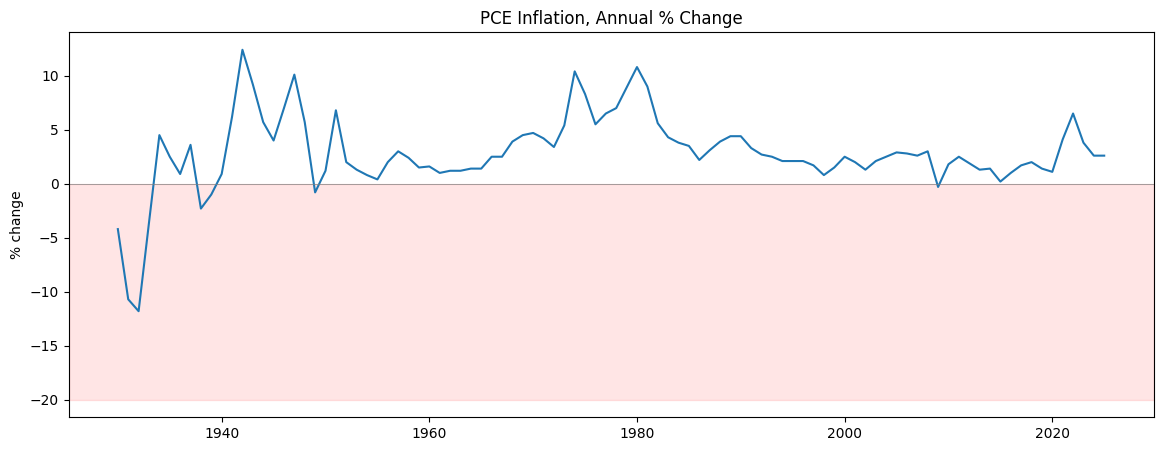

In [43]:
import matplotlib.pyplot as plt

years = df.columns[1:].astype(int)
plt.figure(figsize=(14, 5))
plt.plot(years, df.iloc[0, 1:], label=df.iloc[0, 0])  # overall PCE
plt.axhline(0, color="gray", lw=0.5)
plt.axhspan(-20, 0, alpha=0.1, color="red")  # deflation zone
plt.title("PCE Inflation, Annual % Change")
plt.ylabel("% change")
plt.show()


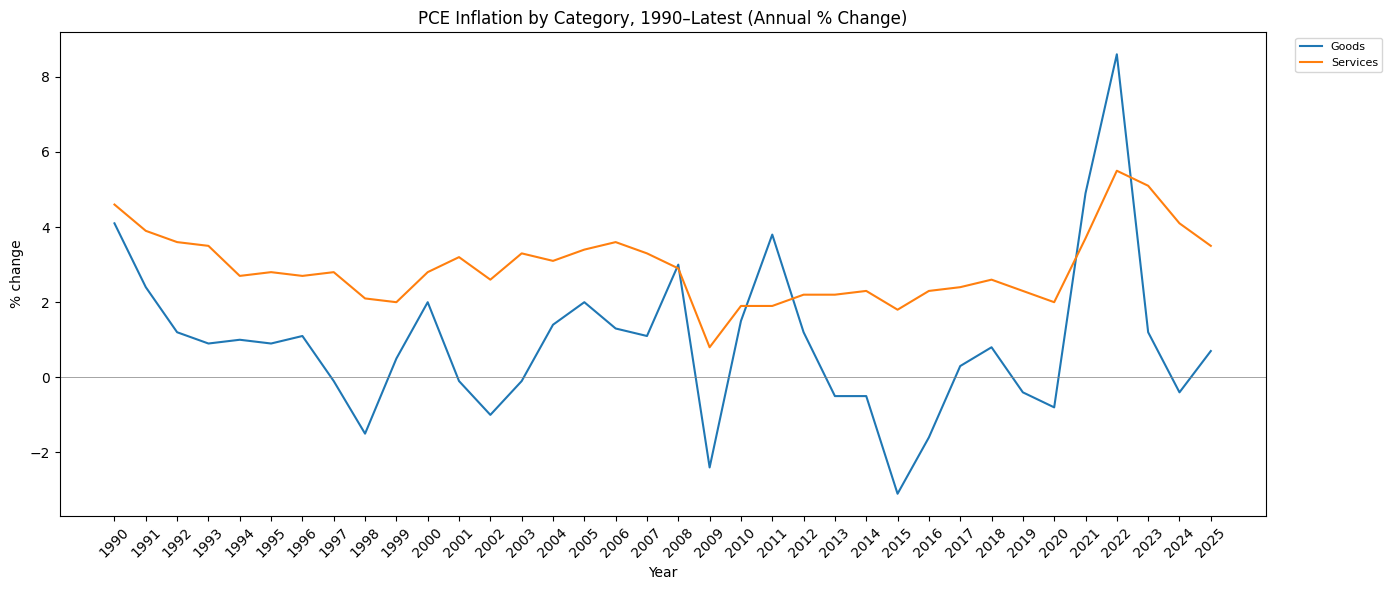

In [44]:
import matplotlib.pyplot as plt

year_cols = [c for c in df.columns if str(c).isdigit() and int(c) >= 1990]
keep = ["Personal consumption expenditures (PCE)", "Goods", "Services", "Food", "Energy goods and services"]
sub = df[df["category"].isin(keep)]
# then loop over sub instead of df

plt.figure(figsize=(14, 6))
for _, row in sub.iterrows():
    plt.plot(year_cols, row[year_cols], label=row["category"])

plt.axhline(0, color="gray", lw=0.5)
plt.title("PCE Inflation by Category, 1990–Latest (Annual % Change)")
plt.ylabel("% change")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


In [46]:
df2 = read_clean("../data/original(do not modify)/GDP_and_personal_income/Personal_Income_and_Outlays/Annual_T2.5.4._Price_Indexes_for_Personal_Consumption_Expenditures_by_Function.xlsx")

In [47]:
df2.to_excel("../data/cleaned/annual_price_indexes_for_PCE.xlsx", index=False)

# House Price

In [51]:
df = read_clean(
    "../data/original(do not modify)/GDP_and_personal_income/Supplemental_Tables/Annual_T7.4.4._Price_Indexes_for_Housing_Sector_Output,_Gross_Value_Added,_and_Net_Value_Added.xlsx"
)

df

,category,1929,1930,1931,1932,1933,1934,1935,1936,1937,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Housing output\1\,9.738,9.460,8.922,7.987,7.168,6.535,6.565,6.714,7.028,...,93.537,96.666,100.0,103.391,106.915,109.977,112.743,119.346,128.391,135.315
1,Nonfarm housing,10.157,9.886,9.360,8.405,7.521,6.772,6.764,6.923,7.241,...,93.494,96.687,100.0,103.375,106.917,109.996,112.747,119.301,128.344,135.242
2,Owner-occupied,10.333,10.057,9.523,8.550,7.369,6.898,6.883,7.045,7.369,...,93.703,96.800,100.0,103.299,106.749,109.743,112.570,119.036,127.924,134.908
3,Tenant-occupied,9.552,9.298,8.803,7.904,7.381,6.363,6.363,6.512,6.812,...,92.826,96.322,100.0,103.626,107.466,110.820,113.319,120.163,129.713,136.332
4,Farm housing,6.170,5.868,5.281,4.556,4.239,4.448,4.750,4.816,5.077,...,97.645,94.599,100.0,104.916,106.649,107.977,112.419,124.220,133.530,143.288
5,Less: Intermediate goods and services consumed,13.703,13.525,12.945,11.929,10.453,9.079,8.979,8.986,9.388,...,89.605,94.722,100.0,103.946,106.505,109.159,115.469,126.143,135.543,145.284
6,Equals: Gross housing value added,9.111,8.831,8.312,7.414,6.674,6.126,6.170,6.333,6.631,...,94.196,96.991,100.0,103.301,106.977,110.106,112.276,118.235,127.218,133.753
7,Nonfarm housing,9.500,9.226,8.719,7.799,7.000,6.344,6.350,6.527,6.829,...,94.158,97.016,100.0,103.283,106.980,110.127,112.275,118.178,127.158,133.664
8,Owner-occupied,9.568,9.298,8.802,7.888,6.811,6.404,6.398,6.567,6.871,...,94.622,97.251,100.0,103.160,106.598,109.808,111.890,117.327,126.105,132.631
9,Tenant-occupied,9.161,8.888,8.383,7.482,7.017,6.101,6.120,6.300,6.591,...,92.663,96.246,100.0,103.699,108.255,111.191,113.563,121.070,130.755,137.187


In [52]:
df.to_excel("../data/cleaned/annual_price_indexes_for_housing_sector_output.xlsx", index=False)

## Medical

In [55]:
df = read_clean("../data/original(do not modify)/GDP_and_personal_income/Personal_Income_and_Outlays/Annual_T2.5.4._Price_Indexes_for_Personal_Consumption_Expenditures_by_Function.xlsx",
                )
df

,category,1929,1930,1931,1932,1933,1934,1935,1936,1937,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Personal consumption expenditures,8.787,8.415,7.514,6.627,6.391,6.681,6.846,6.909,7.16,...,97.299,98.284,100,102.047,103.509,104.666,108.972,116.1,120.511,123.666
1,Household consumption expenditures\1\,8.701,8.331,7.435,6.55,6.317,6.602,6.767,6.827,7.075,...,97.378,98.306,100,102.069,103.493,104.663,108.846,115.818,120.044,123.072
2,Food and beverages purchased for off-premise...,9.219,8.624,6.962,5.692,5.72,6.43,6.94,6.953,7.166,...,101.141,100.13,100,100.517,101.528,104.888,108.159,119.318,125.328,126.956
3,Food and nonalcoholic beverages purchased ...,8.045,7.556,6.143,5.055,5.11,5.816,6.251,6.251,6.469,...,101.581,100.26,100,100.449,101.373,105.013,108.533,121.18,127.671,129.242
4,Alcoholic beverages purchased for off-prem...,.....,.....,.....,.....,14.258,13.563,13.27,13.106,13.239,...,98.517,99.384,100,100.921,102.44,104.277,106.188,109.688,113.353,115.242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,Less: Expenditures in the United States by...,5.546,5.541,5.097,4.712,4.422,4.843,5.226,5.484,5.572,...,97.563,98.087,100,102.173,104.653,103.418,106.104,114.538,117.957,119.631
130,Net expenditures abroad by U.S. residents,.....,.....,.....,.....,.....,.....,.....,.....,.....,...,.....,.....,.....,.....,.....,.....,.....,.....,.....,.....
131,Final consumption expenditures of nonprofit in...,22.026,21.185,19.369,17.999,17.322,18.277,18.413,18.912,19.901,...,94.805,97.582,100,101.337,104.037,104.815,113.155,125.851,136.909,144.806
132,Gross output of nonprofit institutions\29\,.....,.....,.....,.....,.....,.....,.....,.....,.....,...,96.041,97.933,100,102.15,104.529,107.024,111.514,117.35,122.768,127.651


In [64]:
df.loc[130,:].unique()

array(['    Net expenditures abroad by U.S. residents', '.....'],
      dtype=object)

In [66]:
year_cols = [c for c in df.columns if c != "category"]
df[year_cols] = df[year_cols].apply(pd.to_numeric, errors="coerce")


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 134 entries, 0 to 133
Data columns (total 97 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  134 non-null    object 
 1   1929      95 non-null     float64
 2   1930      95 non-null     float64
 3   1931      95 non-null     float64
 4   1932      95 non-null     float64
 5   1933      96 non-null     float64
 6   1934      96 non-null     float64
 7   1935      96 non-null     float64
 8   1936      96 non-null     float64
 9   1937      96 non-null     float64
 10  1938      96 non-null     float64
 11  1939      96 non-null     float64
 12  1940      96 non-null     float64
 13  1941      96 non-null     float64
 14  1942      96 non-null     float64
 15  1943      96 non-null     float64
 16  1944      96 non-null     float64
 17  1945      96 non-null     float64
 18  1946      96 non-null     float64
 19  1947      96 non-null     float64
 20  1948      96 non-null     float64
 21